In [40]:
import tensorflow as tf
from tensorflow import keras
import math
#from keras.layers import Conv2D, Conv2DTranspose, MaxPooling2D, Flatten, Dense, Lambda, Reshape

from keras import ops
from keras import layers

from keras import Model, Input
from keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
import os 
import sys

sys.path.append(os.path.abspath('..'))
from proyecto1_deep_learning.data_loader import load_data_3



In [41]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 7967028706445800006
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 3758096384
locality {
  bus_id: 1
  links {
  }
}
incarnation: 16133513080411386757
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6"
xla_global_id: 416903419
]
2.20.0
Num GPUs Available:  1


I0000 00:00:1771995600.719347   22071 gpu_device.cc:2020] Created device /device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [42]:
##why the helly does this not work?
x_train, x_test = load_data_3()

image_shape = x_train.shape[1:]
num_channels = image_shape[2]
print(f"Image shape: {image_shape}")

Image shape: (128, 128, 3)


In [43]:
x_train.shape, x_test.shape

((168, 128, 128, 3), (43, 128, 128, 3))

In [44]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

print(f'x_train min: {x_train.min()}, max: {x_train.max()}')
print(f'x_test min: {x_test.min()}, max: {x_test.max()}')

x_train min: 0.0, max: 1.0
x_test min: 0.0, max: 1.0


In [45]:
x_train.shape, x_test.shape

((168, 128, 128, 3), (43, 128, 128, 3))

## variational autencoder

to my understanding, generally is:
* we have the original or master latent space whcih we are trying to achieve.
* usually we basically translate neurons language into  a latent space by losing information, and making the language it speaks to say more complex, or so that the general directions which it aims to have mroe meaning. it also means that because each neron has more menaing and is more complex understanding how each position or movement through 3d space makes no sesnse because it chose how to organize itself.
* so in this particalr scenario we give it a language of how to translate into latent space.
* we are basically discifering ho to translate languages or information. so to translate information we first translate the ideal latent space representation or what the model should look like if done like a classic AE, and then we translate as to how taht would look in a noraml distribution. we cast it to a normal distrivution. if we have point a, then its probably in point b, and so on. thus showing spacial relevance.
* and from this normal distribution we can recreate the image.


## first lets do on elike this link:
https://keras.io/examples/generative/vae/ 

In [46]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon


In [47]:
latent_dim = 2
image_size_x = 128
image_size_y = 128

encoder_inputs = keras.Input(shape=(image_size_x, image_size_y, 3))

x = layers.Conv2D(32, 3, strides=2, padding="same")(encoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

shape_before_flattening = x.shape[1:]

x = layers.Flatten()(x)
x = layers.Dense(16)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()


latent_inputs = keras.Input(shape=(latent_dim,))

x = layers.Dense(np.prod(shape_before_flattening))(latent_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Reshape(shape_before_flattening)(x)

x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

decoder_outputs = layers.Conv2DTranspose(
    3, 3, activation="sigmoid", padding="same"
)(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │        896 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 32,    │     18,496 │ activation_15[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 16, 16,    │     73,856 │ activation_16[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 8, 8, 256) │    295,168 │ activation_17[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 16384)     │          0 │ activation_18[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 16)        │    262,160 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 16)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ activation_19[0]

 Total params: 652,628 (2.49 MB)

 Trainable params: 651,636 (2.49 MB)

 Non-trainable params: 992 (3.88 KB)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16384)          │        49,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 16, 16, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 32, 32, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_18             │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_19             │ (None, 128, 128, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,094,851 (4.18 MB)

 Trainable params: 1,061,123 (4.05 MB)

 Non-trainable params: 33,728 (131.75 KB)

In [48]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # MSE loss (no automatic reduction)
            reconstruction_loss = ops.mean(
                ops.sum(
                    ops.square(data - reconstruction),
                    axis=(1, 2, 3),
                )
            )

            # KL divergence
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [49]:
motorcycle_brum_brum = np.concatenate([x_train, x_test], axis=0)


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
history = vae.fit(motorcycle_brum_brum, epochs=60)




Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 876ms/step - kl_loss: 1.4940 - loss: 9153.5186 - reconstruction_loss: 9152.0244
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - kl_loss: 290.3008 - loss: 5193.8667 - reconstruction_loss: 4903.5664
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - kl_loss: 17.1533 - loss: 3153.8621 - reconstruction_loss: 3136.7092
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - kl_loss: 21.9496 - loss: 2543.2798 - reconstruction_loss: 2521.3301
Epoch 5/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - kl_loss: 9.5050 - loss: 2241.4321 - reconstruction_loss: 2231.9272
Epoch 6/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - kl_loss: 20.7027 - loss: 2166.8340 - reconstruction_loss: 2146.1316
Epoch 7/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - kl_loss: 18.0211 - loss: 2140.7429 - reconstruction_loss: 2122.7217
Epoch 8/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - kl_loss: 12.3534 - loss: 2116.9751 - reconstruction_loss: 2104.6216
Epoch 9/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/ste

1/1 ━━━━━━━━━━━━━━━━━━━━ -5s -4695738us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 730ms/step


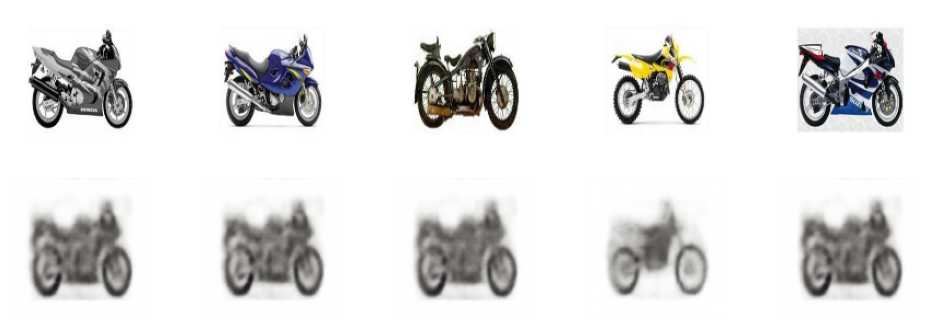

In [50]:
import matplotlib.pyplot as plt
import numpy as np

def show_reconstructions(model, data, n=5):
    z_mean, z_log_var, z = model.encoder.predict(data[:n])
    reconstructions = model.decoder.predict(z)

    plt.figure(figsize=(12, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i])
        plt.axis("off")

        # Reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructions[i])
        plt.axis("off")

    plt.show()

show_reconstructions(vae, motorcycle_brum_brum)

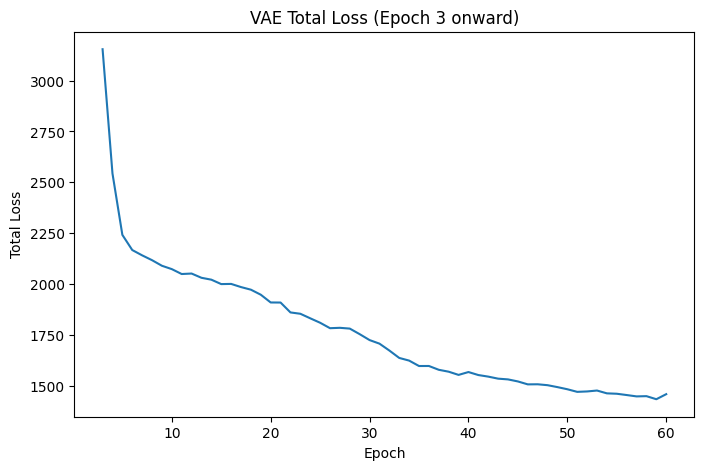

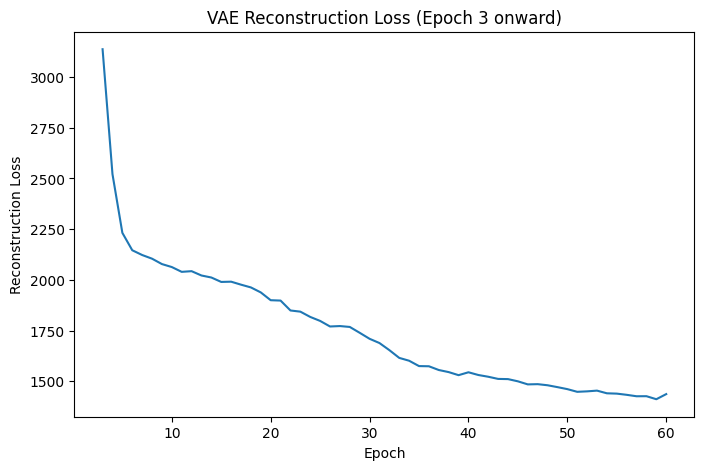

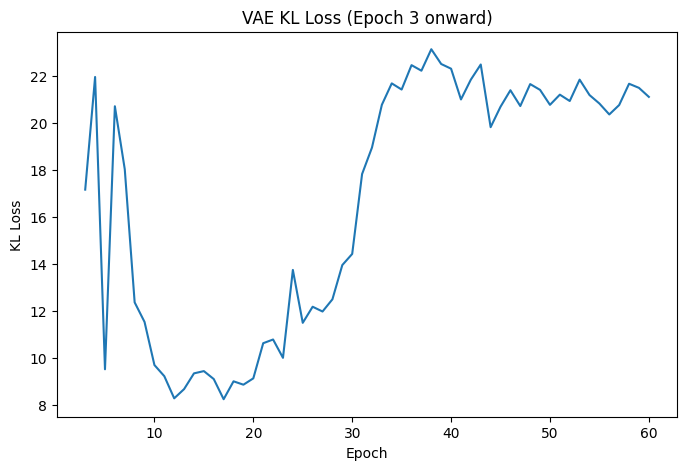

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Ignore first 2 epochs
epochs = np.arange(3, len(history.history["loss"]) + 1)

total_loss = history.history["loss"][2:]
recon_loss = history.history["reconstruction_loss"][2:]
kl_loss = history.history["kl_loss"][2:]

# ---- Total Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, total_loss)
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("VAE Total Loss (Epoch 3 onward)")
plt.show()

# ---- Reconstruction Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, recon_loss)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("VAE Reconstruction Loss (Epoch 3 onward)")
plt.show()

# ---- KL Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, kl_loss)
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.title("VAE KL Loss (Epoch 3 onward)")
plt.show()

In [62]:
LATENT_DIM = 2

def generate_images(
    decoder: keras.Model,
    n_images: int,
) -> np.ndarray:
    """Sample n_images points from N(0, I) and decode them into images.

    Args:
        decoder:   The standalone decoder model.
        n_images:  How many images to generate.

    Returns:
        numpy array of shape (n_images, H, W, C) with pixel values in [0, 1].
    """
    z = np.random.normal(size=(n_images, LATENT_DIM)).astype("float32")
    generated = decoder.predict(z, verbose=0)
    return generated


def plot_generated_images(
    generated: np.ndarray,
    n_images: int,
    save_path: str = None,
) -> None:
    """Plot and save generated images.

    Args:
        generated:  numpy array of generated images.
        n_images:   How many images to plot.
        save_path:  Where to save the figure (auto-named if None).
    """
    cols = min(n_images, 5)
    rows = math.ceil(n_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    fig.suptitle(f"Generated Images (n={n_images})", fontsize=12)

    axes_flat = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes_flat):
        if i < n_images:
            ax.imshow(np.clip(generated[i], 0, 1))
        ax.axis("off")

    plt.tight_layout()

    if save_path is None:
        save_path = f"./reports/figures/3.04-smdeo-generated_images_{n_images}.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Generated images saved to {save_path}")


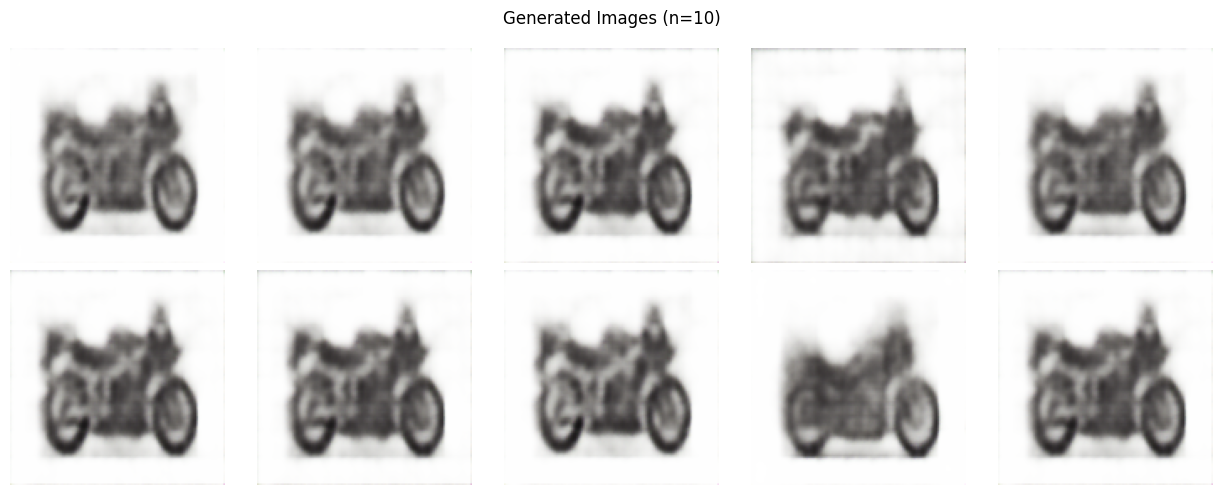

Generated images saved to ./reports/figures/3.04-smdeo-generated_images_10.png


In [63]:
generated_images = generate_images(decoder, n_images=10)
plot_generated_images(generated_images, n_images=10)

In [ ]:
models_path = "./models"

# ---- Save encoder ----
encoder.save(os.path.join(models_path, "encoder_smdo_3-04.keras"))

# ---- Save decoder ----
decoder.save(os.path.join(models_path, "decoder_smdo_3-04.keras"))

# ---- Save full VAE ----
# vae.save("./models/vae_smdo_3-04.keras", include_optimizer=True)
# vae.save("./models/vae_smdo_3-04.keras")
# vae.save("./models/vae_savedmodel_smdo_3-04", save_format="tf")
# vae.save(os.path.join(models_path, "vae_smdo_3-04.keras"))

print("Models saved successfully")


# try:
#     models_path = "../models"

#     # ---- Save encoder ----
#     encoder.save(os.path.join(models_path, "encoder_smdo_3-04.keras"))

#     # ---- Save decoder ----
#     decoder.save(os.path.join(models_path, "decoder_smdo_3-04.keras"))

#     # ---- Save full VAE ----
#     vae.save(os.path.join(models_path, "vae_smdo_3-04.keras"))

#     print("Models saved successfully")
# except Exception as e:
#     models_path = "./models"

#     # ---- Save encoder ----
#     encoder.save(os.path.join(models_path, "encoder_smdo_3-04.keras"))

#     # ---- Save decoder ----
#     decoder.save(os.path.join(models_path, "decoder_smdo_3-04.keras"))

#     # ---- Save full VAE ----
#     vae.save(os.path.join(models_path, "vae_smdo_3-04.keras"))

#     print("Models saved successfully")

NotImplementedError: 
Object VAE was created by passing
non-serializable argument values in `__init__()`,
and therefore the object must override `get_config()` in
order to be serializable. Please implement `get_config()`.

Example:


class CustomLayer(keras.layers.Layer):
    def __init__(self, arg1, arg2, **kwargs):
        super().__init__(**kwargs)
        self.arg1 = arg1
        self.arg2 = arg2

    def get_config(self):
        config = super().get_config()
        config.update({
            "arg1": self.arg1,
            "arg2": self.arg2,
        })
        return config


### checking this saved:

In [64]:
import os

models = [
    "./models/decoder_smdo_3-04.keras",
    "./models/encoder_smdo_3-04.keras",
    "./models/vae_smdo_3-04.keras",
]

for path in models:
    print(f"{path} exists:", os.path.exists(path))

./models/decoder_smdo_3-04.keras exists: True
./models/encoder_smdo_3-04.keras exists: True
./models/vae_smdo_3-04.keras exists: True


In [68]:
from keras.models import load_model

custom_objects = {
    "VAE": VAE,
    "Sampling": Sampling,
}

decoder_loaded = load_model(
    "./models/decoder_smdo_3-04.keras",
    custom_objects=custom_objects
)

encoder_loaded = load_model(
    "./models/encoder_smdo_3-04.keras",
    custom_objects=custom_objects
)

# vae_loaded = load_model(
#     "./models/vae_smdo_3-04.keras",
#     custom_objects=custom_objects
# )

print("All models loaded successfully")

All models loaded successfully


In [69]:
import numpy as np

dummy = np.random.rand(1, 128, 128, 3).astype("float32")

z_mean, z_log_var, z = encoder_loaded.predict(dummy)
print("Encoder output shape:", z.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Encoder output shape: (1, 2)


In [70]:
latent = np.random.normal(size=(1, 2)).astype("float32")
recon = decoder_loaded.predict(latent)
print("Decoder output shape:", recon.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Decoder output shape: (1, 128, 128, 3)


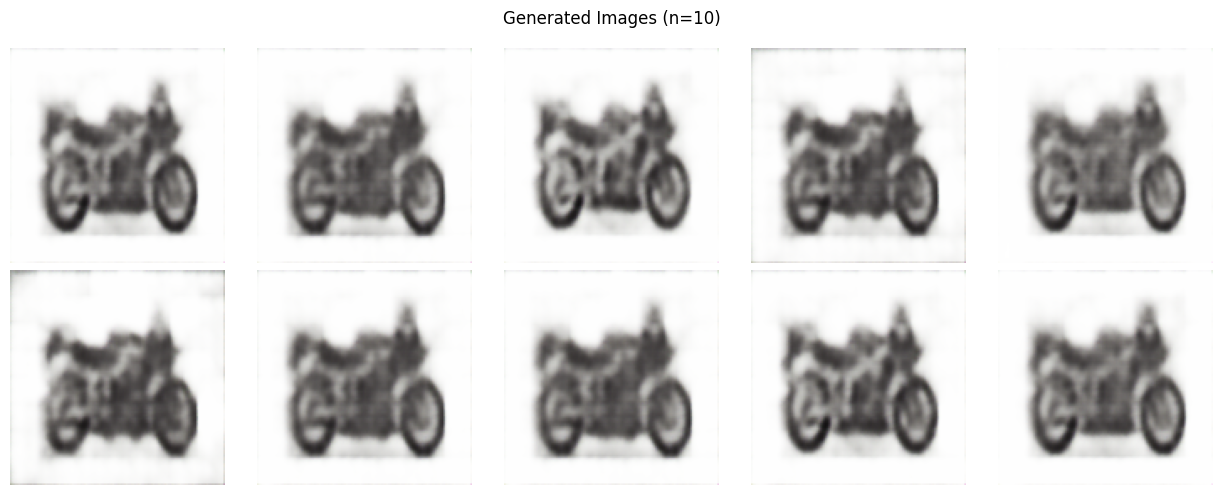

Generated images saved to ./reports/figures/3.04-smdeo-generated_images_10.png


In [72]:
generated_images = generate_images(decoder_loaded, n_images=10)
plot_generated_images(generated_images, n_images=10)